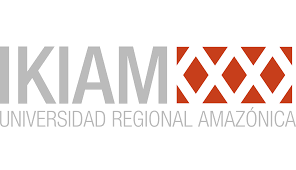

# EXAMEN PARCIAL PYTHON
    

## GBI6-2022II: BIOINFORMÁTICA

Andres Benalcazar

**01-02-2022**

<h1>Datos del equipo</h1>
<table>
  <tr>
    <td>Marca del modelo</td>
    <td>HP</td>  
  </tr>
  <tr>
    <td>Pocesador</td>
    <td>AMD</td> 
  </tr>
  <tr>
    <td>Memoria interna:</td>
    <td>500 GB</td>
  </tr>
  <tr>
    <td>Memoria ram:</td>
    <td>8 GB</td>
  </tr>
  <tr>
    <td>Sistema operativo:</td>
    <td>Windows 10</td>
  </tr>
  <tr>
    <td>Versión del GitBash:</td>
    <td>2.38.1</td>
  </tr>
</table>

### REQUERIMIENTOS PARA EL EXAMEN

Utilice de preferencia ```Jupyter``` de Anaconda, dado que tienen que hacer un control de cambios en cada pregunta. 

Para este examen se requiere dos documentos: 

1. Archivo ```coati.py``` donde tendrá dos funciones:

2. Archivo ```2022II_GBI6_ExamenPython``` donde se llamará las funciones y se obtendrá resultados.

## Ejercicio 0 [0.5 puntos]
Realice cambios al cuaderno de jupyter: 
- Agregue el logo de la Universidad
- Coloque sus datos personales 
- Escriba una <font color='red'>**tabla**</font> con las características de su computador 


## Ejercicio 1 [1.5 puntos]
Inserte la captura de pantalla del curso **PANDAS**
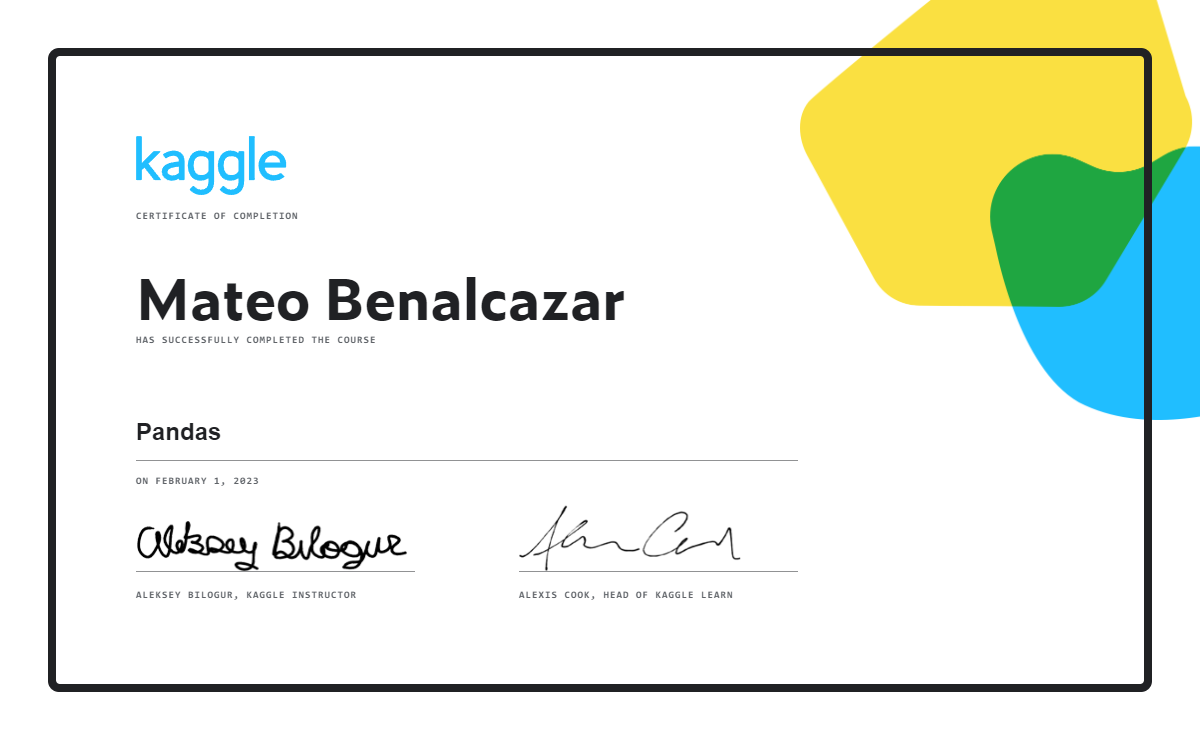

## Ejercicio 2 [1.5 puntos]
Inserte la captura de pantalla del curso [VISUALIZACIÓN]
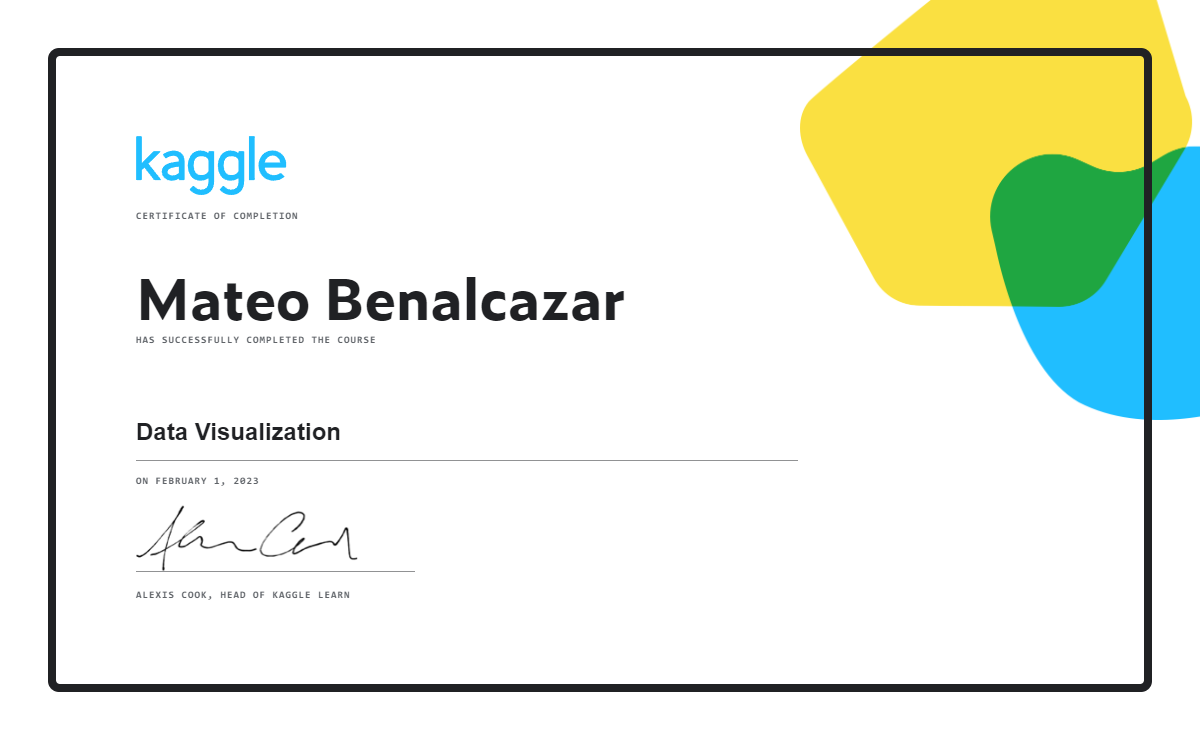

## Ejercicio 3 [3 puntos]

En su carpeta de examen tiene el documento ```id_coati.txt``` donde se encuentran los identificadores de accesión que debe usar para descargar información. 
Cree el módulo ```coati.py``` con las siguientes tres **funciones** y sus respectivos **docstring** :
    
i. ```fasta_downloader```: para cargar ```id_coati.txt``` en ```id_coati```y descargar en **formato genbank** la información correspondiente a los identificadores de accesión usando el **ENTREZ** de Biopythony se guardar en ```coati``` y en ```coati.gb```. 

ii. ```alignment```: para que el algoritmo extraiga **solamente las secuencias** de la variable ```coati``` y realice un alineamiento usando clustalW. El resultado debe ser ```coati.aln``` y ```coati.dnd``` que deben guardarse en su carpeta de trabajo.  

iii ```tree```: para que realice el cálculo de las distancias utilizando ```coati.aln``` y finalmente que imprima en la pantalla el árbol filogenético y guarde en su carpeta de trabajo el arbol como ```coati_phylotree.pdf```

iv. Cargue el módulo ```coati``` e **imprima docstring de cada función**.


In [2]:
# Escriba aquí su código para el ejercicio 3
def fasta_downloader(id_coati):
    """
    Función creada con el fin de cargar los IDs de id_coati.txt, 
    haciendo que la informacion de los identificadores se descage en formarto genbank, 
    todo esto ulizando el ENTREZ de Biopython para guardar el coati y en coati.gb
    """
    
    from Bio import Entrez  
    sequence = open(id_coati, "r") 
    coati = open("data/coati.gb", "w")  
    
    ### descargar la secuencia en formato genbank 
    for linea in sequence: 
        Entrez.email = "andres.benalcazar@est.ikiam.edu.ec"
        handle=Entrez.efetch(db="nucleotide" ,id=linea ,rettype="gb", retmode="text")
        data=(handle.read())
        coati.write(data)  
    
    ### descargamos la secuencia en formato fasta 
    in_sequence_fasta = open(id_coati, "r")
    out_sequence_fasta = open("data/coati.fasta", "w")
    for linea in in_sequence_fasta: 
        Entrez.email = "andres.benalcazar@est.ikiam.edu.ec"
        handle=Entrez.efetch(db="nucleotide" ,id=linea ,rettype="fasta", retmode="text")
        data=(handle.read())
        out_sequence_fasta.write(data)
    out_sequence_fasta.close()
    return coati.close() 

import os
from Bio.Align.Applications import ClustalwCommandline
from Bio import AlignIO
from Bio import Phylo

       
def alignmet(archivo_fasta):
    """
    Función creada para que el algoritmo extraiga solamente    
    las secuencias de la variable coati y realice un alineamiento usando clustalW. 
    El resultado se guardara en coati.aln y coati.dnd.
    """
    
    clustalw_exe = r"C:\Program Files (x86)\ClustalW2\clustalw2.exe" 
    clustalw_cline = ClustalwCommandline(clustalw_exe, infile = archivo_fasta)  
    
    
    assert os.path.isfile(clustalw_exe), "Clustal_W executable is missing or not found"
    stdout, stderr = clustalw_cline()
    print(clustalw_cline)
    ClustalAlign = AlignIO.read("data/coati.aln", "clustal") ## creamos el archivo coati.aln 
    print(ClustalAlign)
    tree = Phylo.read("data/coati.dnd", "newick") ## creamos el dendograma 

    
def tree(alineacion): 
    """
    Funcion que sirve para hacer el cálculo de las distancias 
    utilizando coati.aln para que finalmente imprima en la pantalla el 
    árbol filogenético y guarde en su carpeta de trabajo el arbol como coati_phylotree.pdf
    """
    from Bio.Phylo.TreeConstruction import DistanceCalculator 
    from Bio.Phylo.TreeConstruction import DistanceTreeConstructor
    import matplotlib
    import matplotlib.pyplot as plt
    
     
    with open(alineacion,"r") as aln: 
        alignment = AlignIO.read(aln,"clustal")
    
     
    calculator = DistanceCalculator('identity')
    distance_matrix = calculator.get_distance(alignment)
    constructor = DistanceTreeConstructor(calculator)
   
    # Construir el arbol 
    align_total = constructor.build_tree(alignment)
    align_total.rooted = True
    Phylo.write(align_total, "data/coati.xml", "phyloxml")
    coati_phylotree = Phylo.read(file="data/coati.xml", format= "phyloxml")
    
    # Arbol elemental en Matplotlib
    #fig = Phylo.draw(cis_tree)
    fig = plt.figure(figsize=(30, 40), dpi=100)
    matplotlib.rc('font', size=20)              
    matplotlib.rc('xtick', labelsize=20)     
    matplotlib.rc('ytick', labelsize=20)      
    axes = fig.add_subplot(1, 1, 1)
    Phylo.draw(coati_phylotree, axes=axes)
    fig.savefig('data/coati_phylotree.pdf') 
    return


## Ejercicio 4 [1.5 puntos]

Escriba una o dos líneas de código para usar las funciones ```fasta_downloader```, ```alignment``` y ```tree```: 

i. Descargue la data en ```coati``` y guarde como ```coati.gdb```.  

ii. Alinee las secuencias de ```coati``` y obtenga ```coati.aln``` y ```coati.dnd```.

iii. Construya e **interprete** el arbol filogenético y guarde en ```coati_phylotree.pdf```.

In [3]:
# Escriba aquí su código para el ejercicio 4
import coati as co 
### Descargar los datos 
co.fasta_downloader("data/coati.txt")

In [4]:
import coati as co
### Alinear las secuencias
co.alignment("data/coati.fasta")

"C:\Program Files (x86)\ClustalW2\clustalw2.exe" -infile=data/coati.fasta
Alignment with 49 rows and 717 columns
--------------------------------------------...--- MW419831.1
--------------------------------------------...--- MW419839.1
--------------------------------------------...--- MW419820.1
--------------------------------------------...--- MW419819.1
--------------------------------------------...--- MW419821.1
--------------------------------------------...--- MW419822.1
--------------------------------------------...--- MW419853.1
--------------------------------------------...--- MW419823.1
--------------------------------------------...--- MW419840.1
--------------------------------------------...--- MW419851.1
--------------------------------------------...--- MW419818.1
--------------------------------------------...--- MW419845.1
--------------------------------------------...--- MW419852.1
--------------------------------------------...--- MW419849.1
-------------------

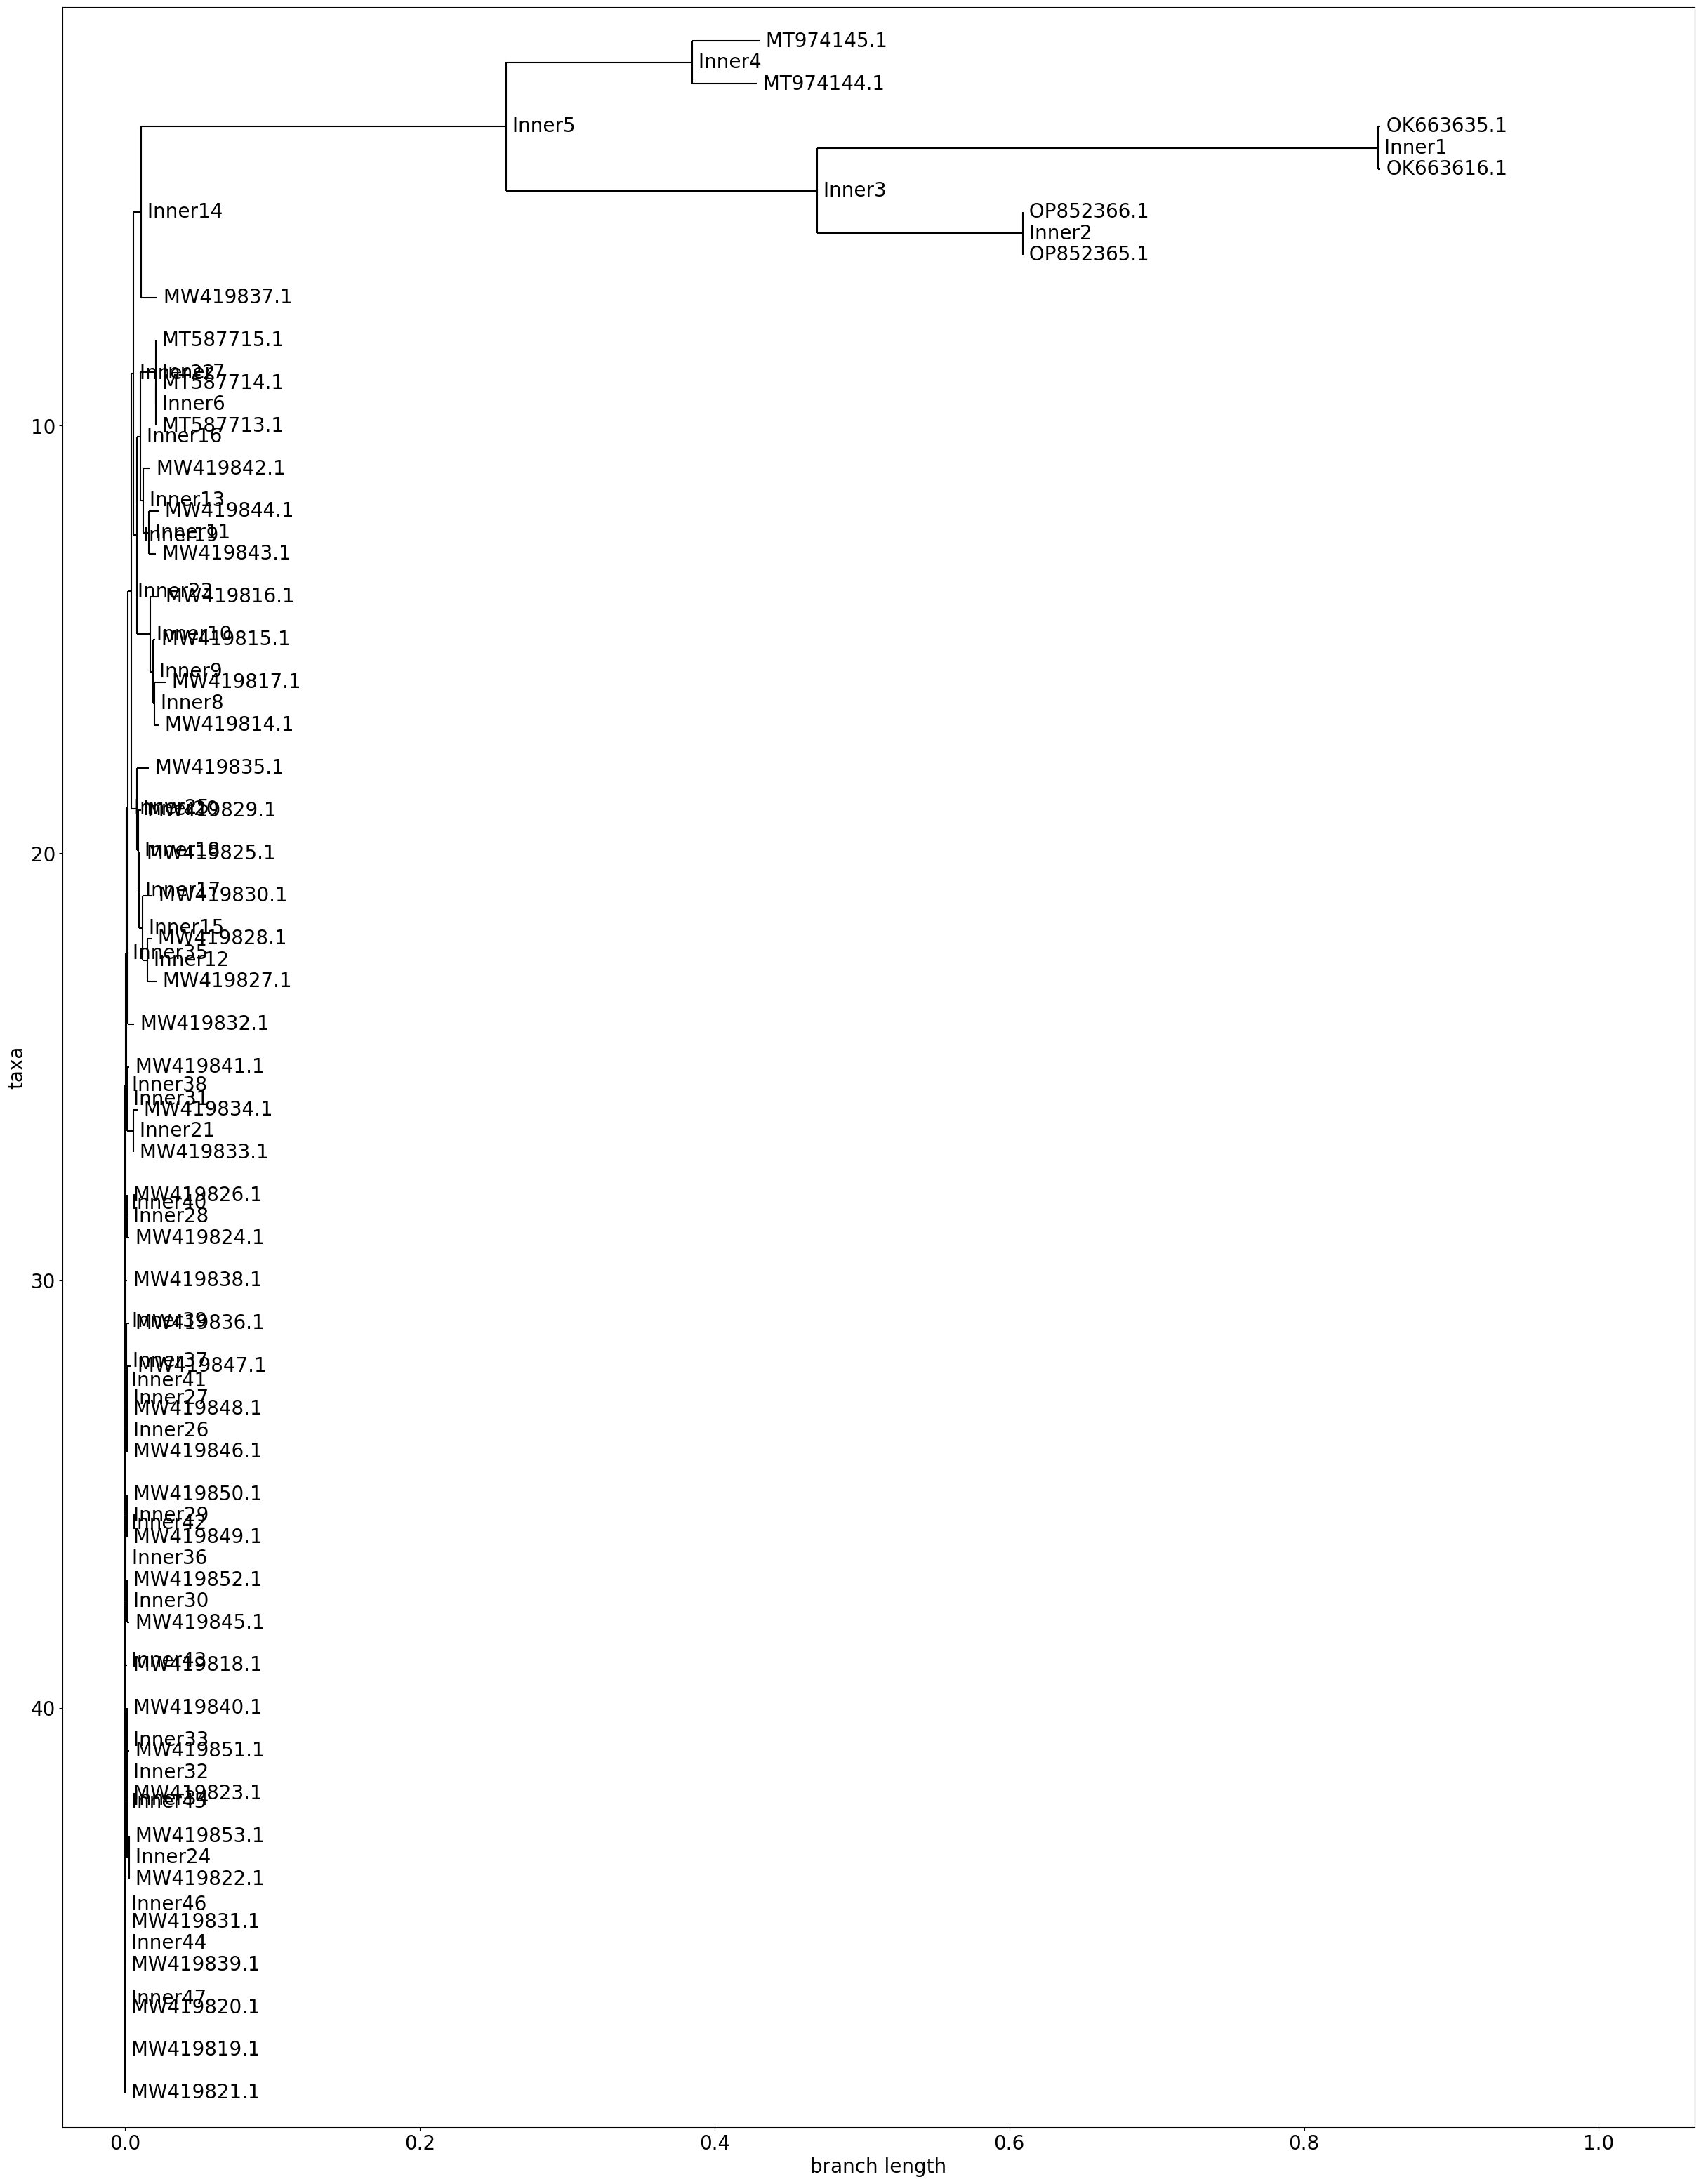

In [5]:
import coati as co
### Construir y graficar el arbol 
co.tree("data/coati.aln")

## Ejercicio 5 [1.5 puntos]

Con las secuencias de ADN de ```coati```, realice lo siguiente: 

i. la traducción y cálculo del peso molecular (**molecular_weight**) y el índice de estabilidad (**instability_index**) de los péptidos resultantes. 

ii. una gráfica tipo [joinplot](https://seaborn.pydata.org/generated/seaborn.jointplot.html#seaborn.jointplot) utilizando los parámetros de peso molecular e índice de estabilidad. Edite color, tamaño y tipo de puntos, asimismo etiquete adecuadamente el título y los ejes.

iii. guarde la figura como ```coati.png``` con una resolución de 300dpi.

iv. interprete la figura resultante

C:\Users\User\anaconda3\lib\site-packages\Bio\Seq.py:2979: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(


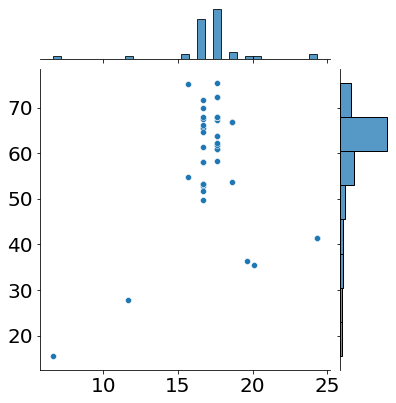

In [8]:
from Bio.SeqUtils import GC 
from Bio import SeqIO 
from Bio.Seq import Seq 
from Bio.SeqUtils.ProtParam import ProteinAnalysis 

peptides = []  
peptides_V1 = [] 
peptides_V2 = []
molecular_weight = []  
instability_index = []

### Traduccion de cada secuencia 
for record in SeqIO.parse("data/coati.fasta", "fasta"):
    peptides.append(record.seq.translate())

### Limpiar secuencias 

for secuencia in peptides: 
    peptides_V1.append(secuencia.replace("*", "N"))
for secuencia in peptides_V1:   
    peptides_V2.append(secuencia.replace("X", "N"))

for seq in peptides_V2: 
    molecular_weight.append(GC(seq))
    f = ProteinAnalysis(str(seq))
    instability_index.append(f.instability_index())

instability_index
### Gráfico 

import seaborn as sns
import matplotlib.pyplot as plt

sns.jointplot(x = molecular_weight, y = instability_index ,
              kind = "scatter")
plt.xlabel("Peso Molecular")
plt.ylabel("Indice de inestabilidad")
plt.savefig("coati.png", dpi = 300)

[41.5057627118644,
 41.5057627118644,
 36.45085470085471,
 35.39615384615386,
 75.19313725490196,
 71.71470588235294,
 67.5813725490196,
 65.5578431372549,
 67.16960784313727,
 67.90882352941178,
 67.90882352941178,
 67.90882352941178,
 66.8921568627451,
 72.21666666666668,
 67.90882352941178,
 61.003921568627455,
 67.90882352941178,
 69.92058823529412,
 61.27156862745098,
 61.003921568627455,
 52.860784313725496,
 67.90882352941178,
 51.63921568627451,
 57.985294117647065,
 65.4892156862745,
 58.05980392156863,
 61.712745098039214,
 53.59509803921569,
 60.88039215686275,
 67.90882352941178,
 72.21666666666668,
 66.06960784313726,
 54.781372549019615,
 64.67058823529413,
 49.79509803921569,
 58.192156862745115,
 67.90882352941178,
 61.712745098039214,
 67.90882352941178,
 63.80784313725491,
 63.80784313725491,
 75.41274509803922,
 62.29313725490197,
 66.8921568627451,
 27.800729927007286,
 15.498529411764698,
 53.19803921568627,
 53.19803921568627,
 53.19803921568627]

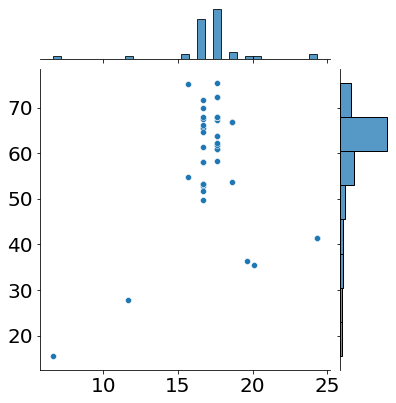

## Ejercicio 6 [0.5 puntos]


1. Cree un archivo ```Readme.md``` que debe tener lo siguiente:
- Datos personales
- Características del computador
- Versión de Python/Anaconda y de cada uno de los módulos/paquetes y utilizados
- Explicación de la data utilizada

2. Asegurarse que su repositorio tiene las carpetas ```data``` e ```img``` con los archivos que ha ido guardando en las preguntas anteriores.  
3. Realice al menos 1 control de la versión (commits) por cada ejercicio (del 1 al 5), con un mensaje que inicie como: 

```sh 
Carlitos Alimaña ha realizado el ejercicio 1  
```
```sh 
Carlitos Alimaña ha realizado el ejercicio 2
```
```sh 
...
```
